In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import interpolate


In [2]:
# Load coordinate and curvature data
x, y = np.loadtxt('down/RuO2-kslice-coord.dat', unpack=True)
zdown = np.loadtxt('down/RuO2-kslice-curv.dat', unpack=True)
zup = np.loadtxt('up/RuO2-kslice-curv.dat', unpack=True)
zmax = 500
zdown = np.where(zdown < zmax, zdown, 0)
zup = np.where(zup < zmax, zup, 0)
print(np.min(zdown), np.max(zdown))

# Calculate ranges for later use
x_range = x.max() - x.min()
y_range = y.max() - y.min()

# Define k-slice plane according to your specification:
# kslice_corner = 0.0 0.0 0.0        ! Gamma point (corner 1)
# kslice_b1 = 0.5 0.5 0.0            ! Direction to M point
# kslice_b2 = 0.0 0.0 0.5            ! Direction to A point (via Z)

# K-point coordinates in fractional coordinates
gamma_point = np.array([0.0, 0.0, 0.0])  # Γ point
M_point = np.array([0.5, 0.5, 0.0])      # M point  
A_point = np.array([0.0, 0.0, 0.5])      # A point

print(f"Data shape: x={len(x)}, y={len(y)}")
print(f"Berry curvature components: {len(zup)} (x, y, z components)")
print(f"X range: {x.min():.3f} to {x.max():.3f}")
print(f"Y range: {y.min():.3f} to {y.max():.3f}")
print(f"x_range = {x_range:.3f}, y_range = {y_range:.3f}")

-1617.8179 470.32724
Data shape: x=25921, y=25921
Berry curvature components: 3 (x, y, z components)
X range: 0.000 to 0.979
Y range: 0.000 to 1.003
x_range = 0.979, y_range = 1.003


Global color range: min=-1617.8179, max=470.3272
x-component range: min=-502.8841, max=470.3272
y-component range: min=-487.0566, max=465.0231
z-component range: min=-1617.8179, max=5.7184


C:\Users\ASUS\AppData\Local\Temp\ipykernel_35140\3893363969.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


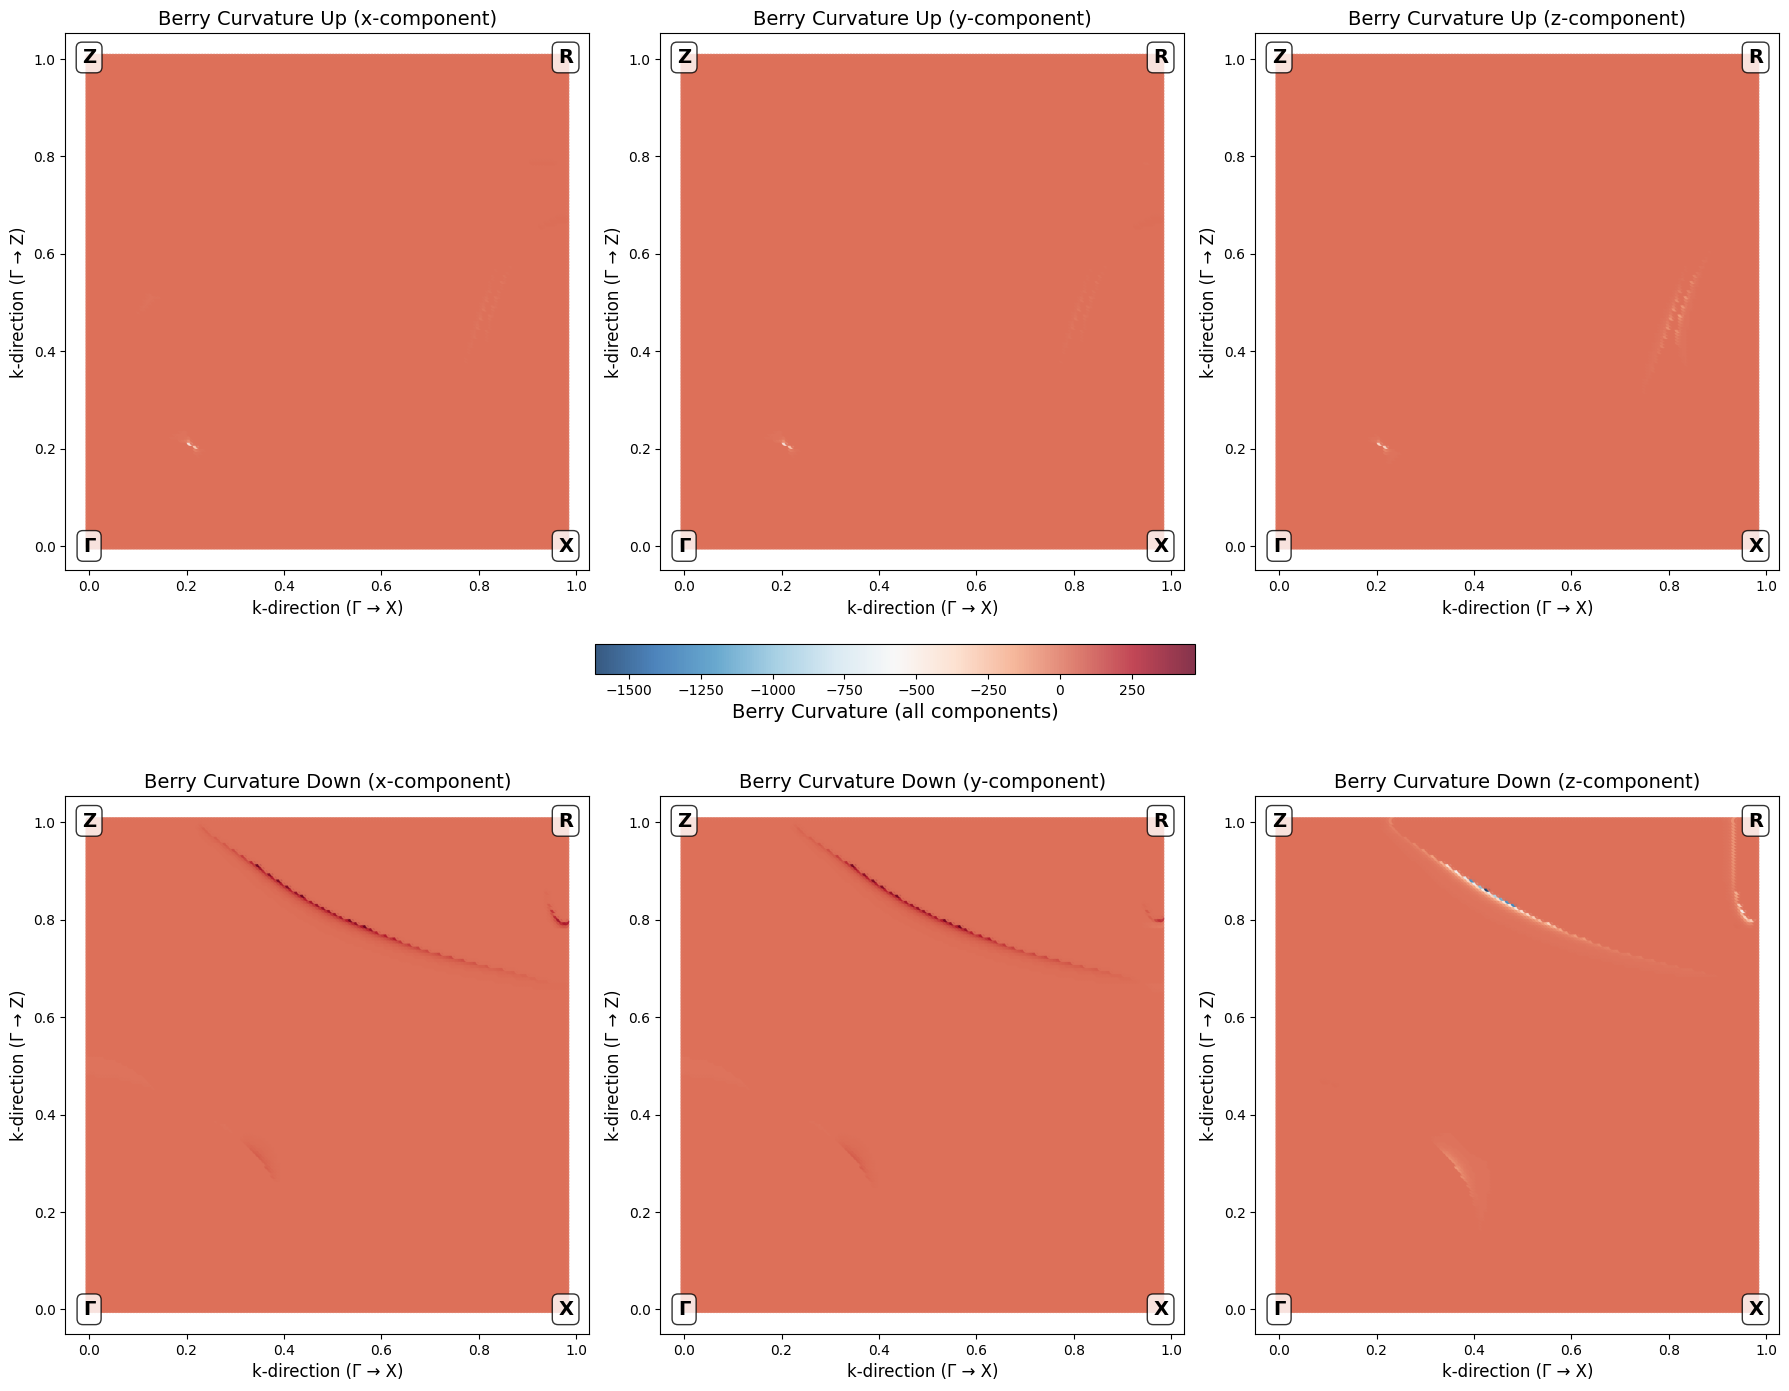

In [6]:
# Create figure with subplots for all three Berry curvature components
fig, axes = plt.subplots(2, 3, figsize=(18, 15))

# Component names
components = ['x', 'y', 'z']

# Calculate global color range for ALL components (shared across x, y, z)
vmin_global = min(np.min(zup[0]), np.min(zup[1]), np.min(zup[2]), 
                  np.min(zdown[0]), np.min(zdown[1]), np.min(zdown[2]))
vmax_global = max(np.max(zup[0]), np.max(zup[1]), np.max(zup[2]), 
                  np.max(zdown[0]), np.max(zdown[1]), np.max(zdown[2]))

print(f'Global color range: min={vmin_global:.4f}, max={vmax_global:.4f}')

# Store scatter plot for colorbar reference
scatter_ref = None

for i, comp_name in enumerate(components):
    # Print individual component ranges for reference
    vmin_comp = min(np.min(zup[i]), np.min(zdown[i]))
    vmax_comp = max(np.max(zup[i]), np.max(zdown[i]))
    print(f'{comp_name}-component range: min={vmin_comp:.4f}, max={vmax_comp:.4f}')
    
    # Plot for up component (top row) - using global color scale
    scatter_up = axes[0, i].scatter(x, y, c=zup[i], cmap='RdBu_r', s=20, alpha=0.8, 
                                    vmin=vmin_global, vmax=vmax_global)
    axes[0, i].set_xlabel('k-direction (Γ → X)', fontsize=12)
    axes[0, i].set_ylabel('k-direction (Γ → Z)', fontsize=12)
    axes[0, i].set_title(f'Berry Curvature Up ({comp_name}-component)', fontsize=14)
    
    if x_range > 0.3 and y_range > 0.3:
        axes[0, i].text(x.min(), y.min(), 'Γ', fontsize=14, fontweight='bold',
                       ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
        axes[0, i].text(x.max(), y.min(), 'X', fontsize=14, fontweight='bold',
                       ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
        axes[0, i].text(x.min(), y.max(), 'Z', fontsize=14, fontweight='bold',
                       ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
        axes[0, i].text(x.max(), y.max(), 'R', fontsize=14, fontweight='bold',
                       ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    axes[0, i].tick_params(labelsize=10)
    axes[0, i].set_aspect('equal')

    # Plot for down component (bottom row) - using global color scale
    scatter_down = axes[1, i].scatter(x, y, c=zdown[i], cmap='RdBu_r', s=20, alpha=0.8,
                                      vmin=vmin_global, vmax=vmax_global)
    axes[1, i].set_xlabel('k-direction (Γ → X)', fontsize=12)
    axes[1, i].set_ylabel('k-direction (Γ → Z)', fontsize=12)
    axes[1, i].set_title(f'Berry Curvature Down ({comp_name}-component)', fontsize=14)
    
    if x_range > 0.3 and y_range > 0.3:
        axes[1, i].text(x.min(), y.min(), 'Γ', fontsize=14, fontweight='bold',
                       ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
        axes[1, i].text(x.max(), y.min(), 'X', fontsize=14, fontweight='bold',
                       ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
        axes[1, i].text(x.min(), y.max(), 'Z', fontsize=14, fontweight='bold',
                       ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
        axes[1, i].text(x.max(), y.max(), 'R', fontsize=14, fontweight='bold',
                       ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    axes[1, i].tick_params(labelsize=10)
    axes[1, i].set_aspect('equal')
    
    # Store reference for shared colorbar
    if scatter_ref is None:
        scatter_ref = scatter_up

# Add single shared horizontal colorbar below all subplots
cbar = fig.colorbar(scatter_ref, ax=axes, orientation='horizontal', fraction=0.04, pad=0.08)
cbar.ax.set_position([0.25, 0.45, 0.5, 0.02])  # [left, bottom, width, height] in figure coordinates
cbar.set_label('Berry Curvature (all components)', fontsize=14)

plt.tight_layout()
plt.show()

NameError: name 'X_grid' is not defined

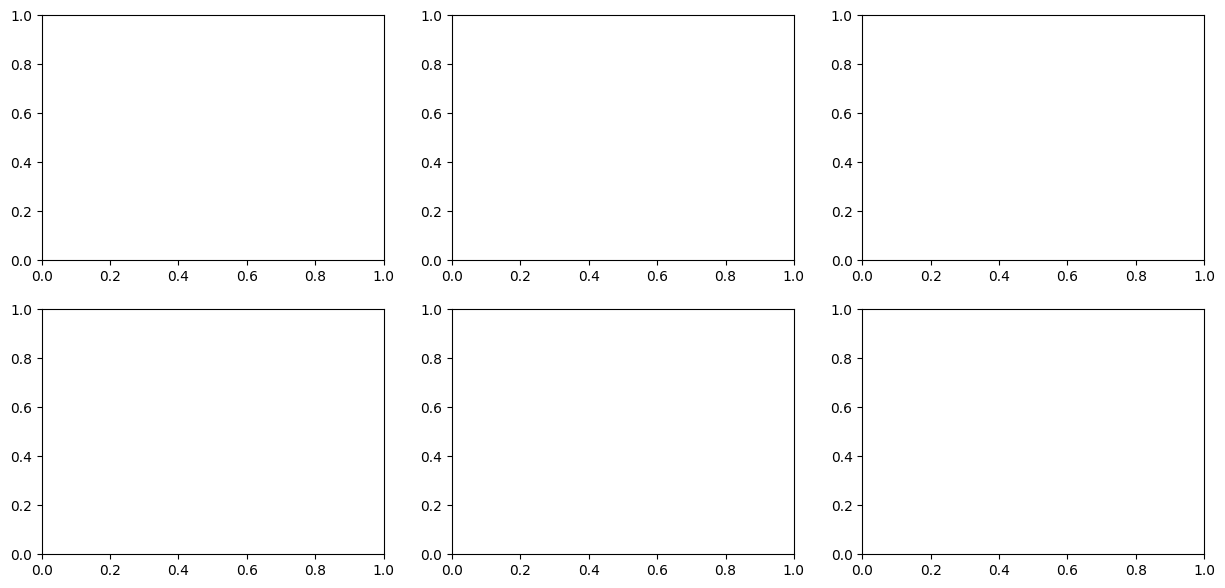

In [4]:
# Plot interpolated contour maps for all three Berry curvature components
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
levels = 50

for idx, comp_name in enumerate(components):
        # Up component (zup)
        ax_up = axes[0, idx]
        comp_interp_up = interpolate.griddata((x, y), zup[idx], (X_grid, Y_grid), method='cubic', fill_value=0)
        vmin_up = np.min(zup[idx])
        vmax_up = np.max(zup[idx])
        contour_up = ax_up.contourf(X_grid, Y_grid, comp_interp_up, levels=levels, cmap='RdBu_r', vmin=vmin_up, vmax=vmax_up, extend='both')
        cbar_up = plt.colorbar(contour_up, ax=ax_up)
        cbar_up.set_label(f'Berry Curvature Up ({comp_name})', fontsize=12)
        ax_up.scatter(x, y, c=zup[idx], cmap='RdBu_r', s=8, edgecolors='black', linewidth=0.2, alpha=0.7, vmin=vmin_up, vmax=vmax_up)
        ax_up.set_xlabel('k-direction (Γ → M)', fontsize=12)
        ax_up.set_ylabel('k-direction (Γ → Z)', fontsize=12)
        ax_up.set_title(f'Berry Curvature Up ({comp_name}-component)', fontsize=14)
        if x_range > 0.3 and y_range > 0.3:
                ax_up.text(x_min, y_min, 'Γ', fontsize=13, fontweight='bold', ha='left', va='bottom',
                                   bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
                ax_up.text(x_max, y_min, 'M', fontsize=13, fontweight='bold', ha='right', va='bottom',
                                   bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
                ax_up.text(x_min, y_max, 'Z', fontsize=13, fontweight='bold', ha='left', va='top',
                                   bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
                ax_up.text(x_max, y_max, 'A', fontsize=13, fontweight='bold', ha='right', va='top',
                                   bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
        ax_up.grid(True, alpha=0.3, linestyle='--')
        ax_up.set_aspect('equal')

        # Down component (zdown)
        ax_down = axes[1, idx]
        comp_interp_down = interpolate.griddata((x, y), zdown[idx], (X_grid, Y_grid), method='cubic', fill_value=0)
        vmin_down = np.min(zdown[idx])
        vmax_down = np.max(zdown[idx])
        contour_down = ax_down.contourf(X_grid, Y_grid, comp_interp_down, levels=levels, cmap='RdBu_r', vmin=vmin_down, vmax=vmax_down, extend='both')
        cbar_down = plt.colorbar(contour_down, ax=ax_down)
        cbar_down.set_label(f'Berry Curvature Down ({comp_name})', fontsize=12)
        ax_down.scatter(x, y, c=zdown[idx], cmap='RdBu_r', s=8, edgecolors='black', linewidth=0.2, alpha=0.7, vmin=vmin_down, vmax=vmax_down)
        ax_down.set_xlabel('k-direction (Γ → M)', fontsize=12)
        ax_down.set_ylabel('k-direction (Γ → Z)', fontsize=12)
        ax_down.set_title(f'Berry Curvature Down ({comp_name}-component)', fontsize=14)
        if x_range > 0.3 and y_range > 0.3:
                ax_down.text(x_min, y_min, 'Γ', fontsize=13, fontweight='bold', ha='left', va='bottom',
                                         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
                ax_down.text(x_max, y_min, 'M', fontsize=13, fontweight='bold', ha='right', va='bottom',
                                         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
                ax_down.text(x_min, y_max, 'Z', fontsize=13, fontweight='bold', ha='left', va='top',
                                         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
                ax_down.text(x_max, y_max, 'A', fontsize=13, fontweight='bold', ha='right', va='top',
                                         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
        ax_down.grid(True, alpha=0.3, linestyle='--')
        ax_down.set_aspect('equal')

plt.tight_layout()
plt.show()


In [ ]:
np.max(zup[0]), np.max(zup[1]), np.max(zup[2])

(np.float64(0.070495136), np.float64(5.0397163), np.float64(0.068837528))